### CardioRisk ML
#### Exploratory Data Analysis

In this notebook I perform an exploratory analysis of the dataset generated in
the previous step, with the goal of understanding the data structure, the
distributions of clinical variables, and the relationships between risk factors
and the target.

The EDA answers fundamental questions before modelling:

- How are clinical variables distributed across risk groups?
- Which factors correlate most strongly with cardiovascular risk?
- Are there meaningful differences between sexes and age groups?
- What is the typical profile of a high-risk patient?

The insights generated here will guide feature engineering, variable selection,
and modelling strategy in subsequent notebooks.

In [1]:
"""
Environment setup.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Paths
DATA_PATH   = Path("../data/raw/")
FIGURES_DIR = Path("../data/eda_charts")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# Colour palette 
COLOR_LOW  = "#2ECC71" 
COLOR_HIGH = "#E74C3C"   
COLOR_MALE = "#2980B9"   
COLOR_FEM  = "#C0392B"  

# Plot defaults 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)


def save_plot(name: str) -> None:
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

#### Data Loading

In [2]:
"""
Brief summary to confirm the file was loaded correctly and
to surface any unexpected class imbalance before plotting.
"""

df = pd.read_csv(DATA_PATH / "cardiovascular_patients.csv")

print(f"Dataset  : {df.shape[0]:,} patients  ×  {df.shape[1]} variables")
print(f"High risk: {df['cardiovascular_risk'].mean() * 100:.1f}%")
print(f"Dtypes   :\n{df.dtypes.value_counts().to_string()}")

Dataset  : 10,000 patients  ×  28 variables
High risk: 40.3%
Dtypes   :
float64    13
int64       9
object      6


#### Target Distribution

Before any analysis I need to understand the class balance. A heavily
imbalanced dataset can lead a model to always predict the majority class,
achieving high accuracy with no clinical value.

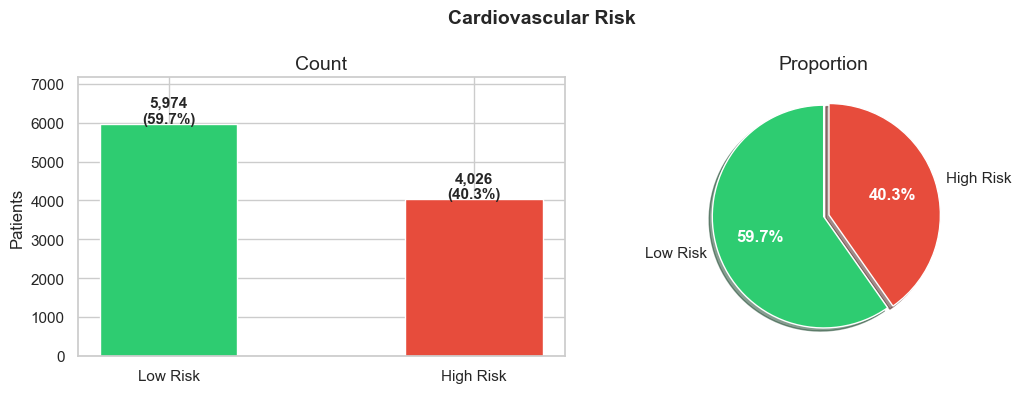

In [3]:
"""
I display both absolute counts and proportions so that any imbalance is
immediately visible and can inform the resampling strategy in Notebook 03.
"""

counts = df["cardiovascular_risk"].value_counts().sort_index()
labels = ["Low Risk", "High Risk"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Cardiovascular Risk",
             fontsize=14, fontweight="bold")

# Bar chart
bars = axes[0].bar(
    labels, [counts[0], counts[1]],
    color=[COLOR_LOW, COLOR_HIGH],
    edgecolor="white", width=0.45,
)
for bar, c in zip(bars, [counts[0], counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f"{c:,}\n({c / len(df) * 100:.1f}%)",
        ha="center", fontsize=11, fontweight="bold",
    )
axes[0].set_ylabel("Patients")
axes[0].set_ylim(0, counts[0] * 1.20)
axes[0].set_title("Count")

# Pie chart
wedges, _, pct_texts = axes[1].pie(
    [counts[0], counts[1]],
    labels=labels,
    colors=[COLOR_LOW, COLOR_HIGH],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),
    shadow=True,
)
for t in pct_texts:
    t.set_fontweight("bold")
    t.set_color("white")
axes[1].set_title("Proportion")

plt.tight_layout()
save_plot("01_target")
plt.show()

#### Demographic Profile

I assess how cardiovascular risk is distributed across sexes and ethnic groups,
and compare age distributions between the two risk classes.

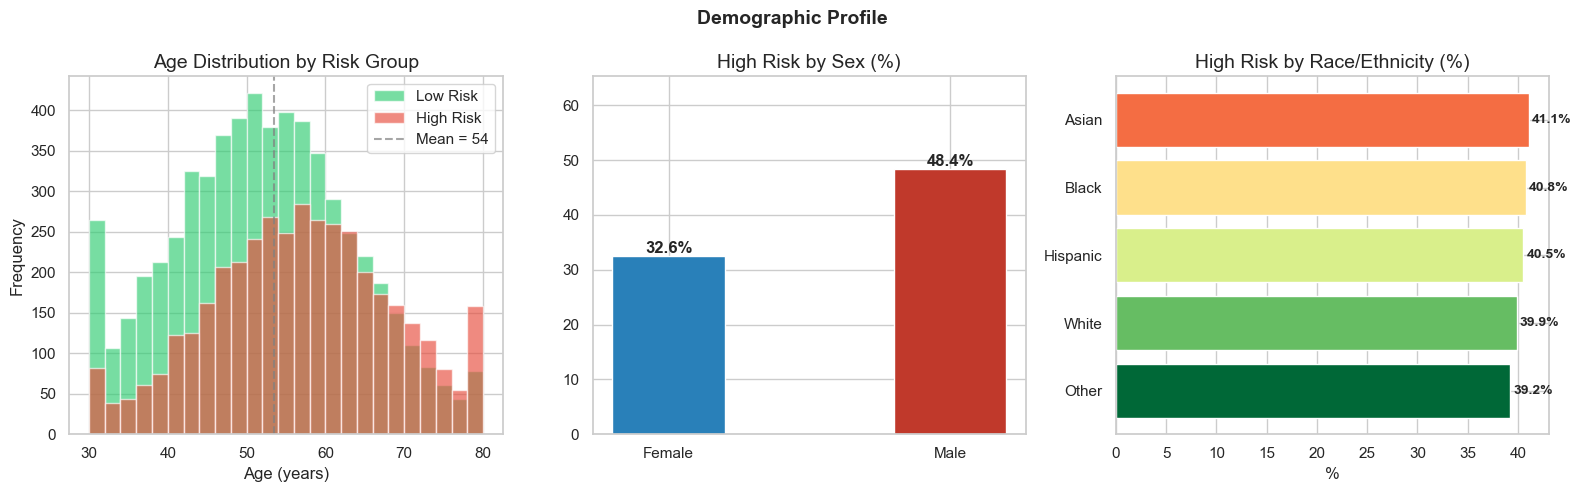

In [4]:
"""
Age distribution and high-risk prevalence by sex and race/ethnicity.
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Demographic Profile", fontsize=14, fontweight="bold")

# Age distribution by risk group 
for label, grp, color in [
    ("Low Risk",  df[df.cardiovascular_risk == 0], COLOR_LOW),
    ("High Risk", df[df.cardiovascular_risk == 1], COLOR_HIGH),
]:
    axes[0].hist(grp["age"], bins=25, alpha=0.65,
                 color=color, label=label, edgecolor="white")
axes[0].axvline(df["age"].mean(), color="gray",
                linestyle="--", alpha=0.7, label=f"Mean = {df['age'].mean():.0f}")
axes[0].set_title("Age Distribution by Risk Group")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# High-risk prevalence by sex 
sex_risk = df.groupby("sex")["cardiovascular_risk"].mean() * 100
bars = axes[1].bar(
    sex_risk.index, sex_risk.values,
    color=[COLOR_MALE, COLOR_FEM],
    edgecolor="white", width=0.4,
)
for bar, v in zip(bars, sex_risk.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v + 0.5,
        f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold",
    )
axes[1].set_title("High Risk by Sex (%)")
axes[1].set_ylim(0, sex_risk.max() * 1.35)

# High-risk prevalence by race/ethnicity 
race_risk = (
    df.groupby("race")["cardiovascular_risk"]
    .mean()
    .sort_values() * 100
)
palette = plt.cm.RdYlGn_r(range(0, 256, 256 // len(race_risk)))
bars = axes[2].barh(race_risk.index, race_risk.values,
                    color=palette, edgecolor="white")
for bar, v in zip(bars, race_risk.values):
    axes[2].text(
        v + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%", va="center", fontsize=10, fontweight="bold",
    )
axes[2].set_title("High Risk by Race/Ethnicity (%)")
axes[2].set_xlabel("%")

plt.tight_layout()
save_plot("02_demographic")
plt.show()

#### Clinical Variable Distributions

For each clinical variable I compare the density distributions between the two
risk groups. Vertical dashed lines mark the clinical thresholds above, or below
for HDL, which the parameter is considered pathological.

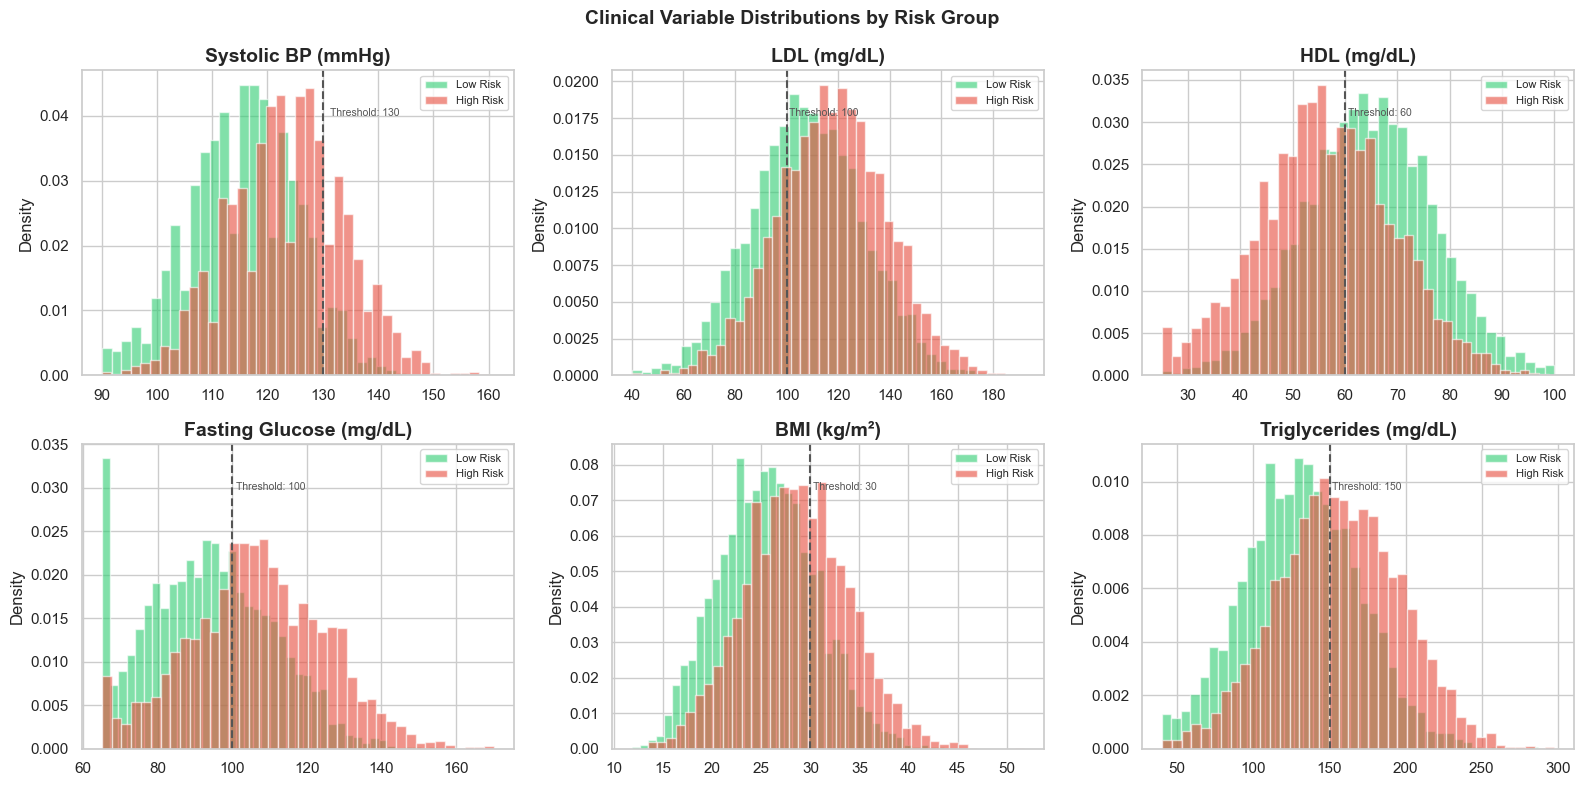

In [5]:
"""
Density histograms for key clinical variables, stratified by risk group.
I include a clinical threshold line for each variable so the viewer can
immediately see where the high-risk population sits relative to
established diagnostic cut-offs.
"""

# column, axis label, clinical threshold
variables = [
    ("systolic_bp_mmhg",      "Systolic BP (mmHg)",       130),
    ("ldl_mg_dl",             "LDL (mg/dL)",               100),
    ("hdl_mg_dl",             "HDL (mg/dL)",                60),
    ("fasting_glucose_mg_dl", "Fasting Glucose (mg/dL)",   100),
    ("bmi",                   "BMI (kg/m²)",                30),
    ("triglycerides_mg_dl",   "Triglycerides (mg/dL)",     150),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Clinical Variable Distributions by Risk Group",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, (col, title, threshold) in zip(axes, variables):
    for label, grp, color in [
        ("Low Risk",  df[df.cardiovascular_risk == 0], COLOR_LOW),
        ("High Risk", df[df.cardiovascular_risk == 1], COLOR_HIGH),
    ]:
        ax.hist(grp[col], bins=40, alpha=0.60, color=color,
                label=label, edgecolor="white", density=True)
    ax.axvline(threshold, color="#555", linestyle="--", linewidth=1.5)
    ax.text(
        threshold * 1.01,
        ax.get_ylim()[1] * 0.85,
        f"Threshold: {threshold}",
        fontsize=7.5, color="#555",
    )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
save_plot("03_distributions")
plt.show()

#### Correlation Map

The heatmap reveals which variables move together and which have the strongest
linear relationship with the target. This helps with feature selection and
multicollinearity detection ahead of modelling.

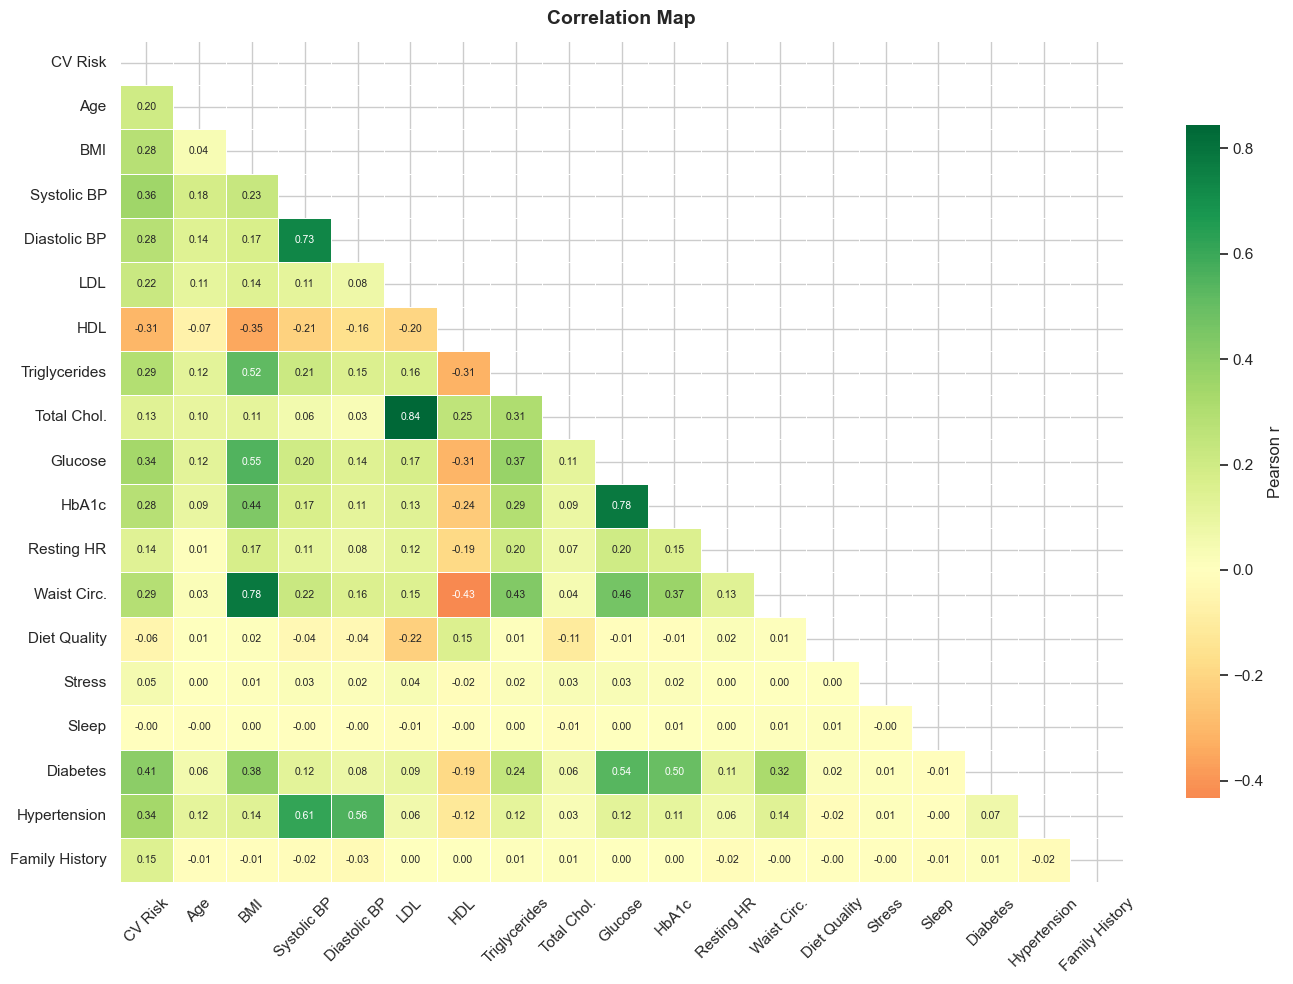

In [6]:
"""
I mask the upper triangle to avoid redundancy and use a diverging
red-yellow-green palette so positive and negative correlations are
immediately distinguishable.
"""

corr_cols = [
    "cardiovascular_risk", "age", "bmi", "systolic_bp_mmhg",
    "diastolic_bp_mmhg", "ldl_mg_dl", "hdl_mg_dl", "triglycerides_mg_dl",
    "total_cholesterol_mg_dl", "fasting_glucose_mg_dl", "hba1c_pct",
    "resting_hr_bpm", "waist_circumference_cm", "diet_quality",
    "stress_level", "sleep_hours", "diabetes", "hypertension", "family_history_cvd",
]

pretty_labels = [
    "CV Risk", "Age", "BMI", "Systolic BP", "Diastolic BP",
    "LDL", "HDL", "Triglycerides", "Total Chol.", "Glucose", "HbA1c",
    "Resting HR", "Waist Circ.", "Diet Quality",
    "Stress", "Sleep", "Diabetes", "Hypertension", "Family History",
]

corr_matrix = df[corr_cols].corr()
corr_matrix.index   = pretty_labels
corr_matrix.columns = pretty_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 7.5}, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Correlation Map", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
save_plot("04_correlation")
plt.show()

In [7]:
"""
Top-10 variables most correlated with cardiovascular risk.
"""

target_corr = (
    df[corr_cols]
    .corr()["cardiovascular_risk"]
    .drop("cardiovascular_risk")
    .abs()
    .sort_values(ascending=False)
)

print("Correlation with Cardiovascular Risk  (|r|):")
print("-" * 40)
for rank, (col, val) in enumerate(target_corr.head(10).items(), 1):
    idx   = corr_cols.index(col)     # corr_cols and pretty_labels are aligned from 0
    label = pretty_labels[idx]
    print(f"  {rank:>2}. {label:<25}  r = {val:.3f}")

Correlation with Cardiovascular Risk  (|r|):
----------------------------------------
   1. Diabetes                   r = 0.405
   2. Systolic BP                r = 0.355
   3. Glucose                    r = 0.340
   4. Hypertension               r = 0.338
   5. HDL                        r = 0.306
   6. Triglycerides              r = 0.292
   7. Waist Circ.                r = 0.287
   8. HbA1c                      r = 0.284
   9. Diastolic BP               r = 0.281
  10. BMI                        r = 0.279


#### Risk Group Comparison With Boxplots

Boxplots show the median, quartiles, and outliers for each variable across the
two groups. The black diamond marks the mean, and the delta label quantifies
the relative difference between group means.

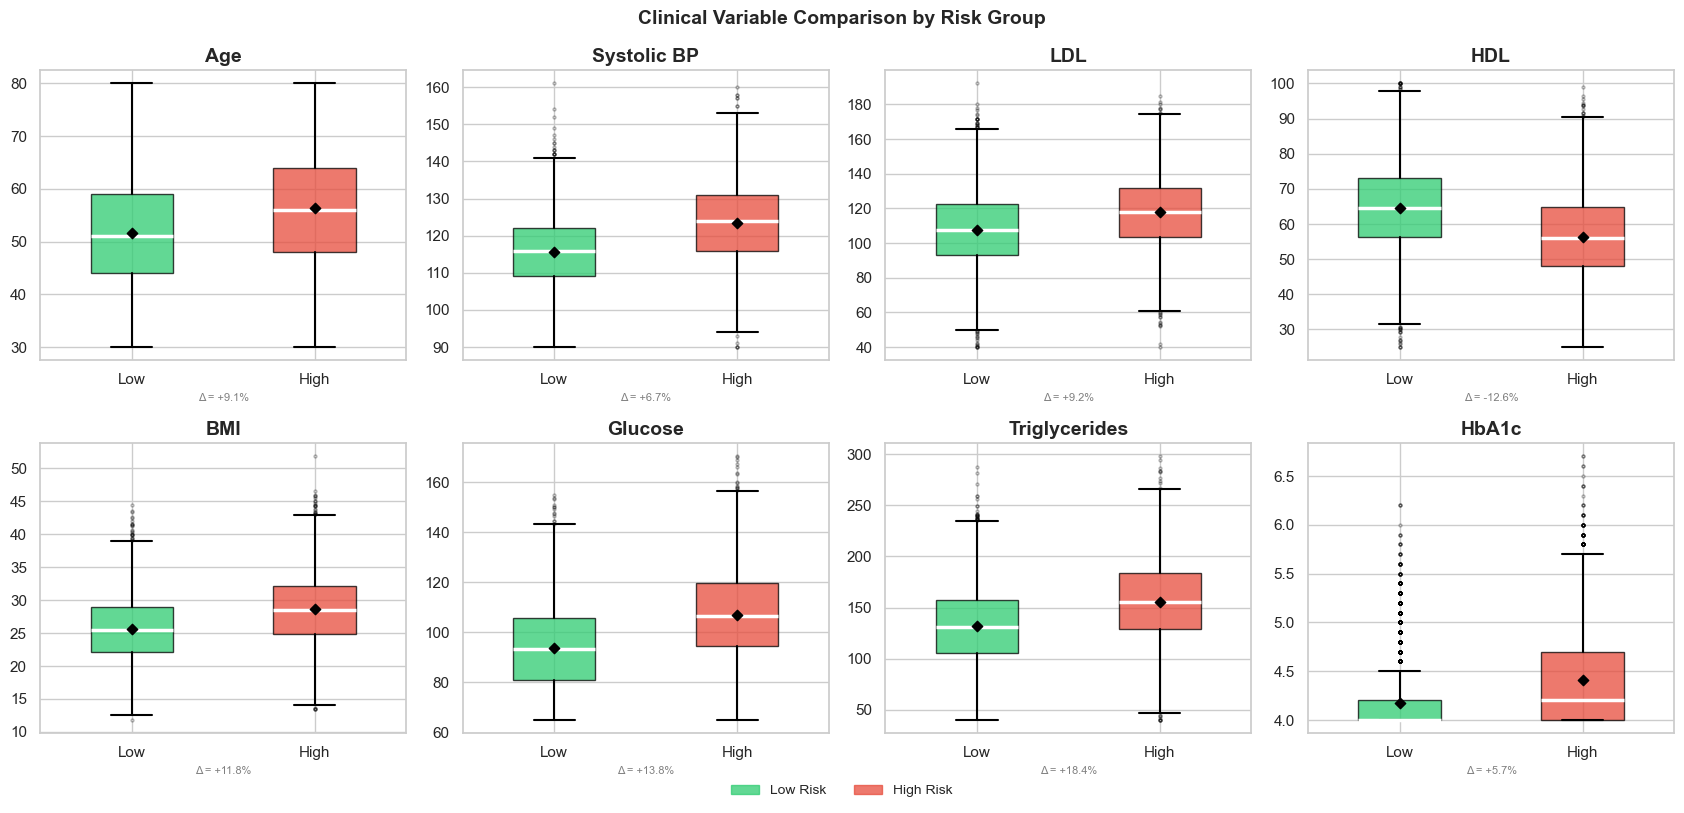

In [8]:
"""
Side-by-side boxplots comparing low-risk and high-risk groups.
"""

box_vars = [
    ("age",                   "Age"),
    ("systolic_bp_mmhg",      "Systolic BP"),
    ("ldl_mg_dl",             "LDL"),
    ("hdl_mg_dl",             "HDL"),
    ("bmi",                   "BMI"),
    ("fasting_glucose_mg_dl", "Glucose"),
    ("triglycerides_mg_dl",   "Triglycerides"),
    ("hba1c_pct",             "HbA1c"),
]

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
fig.suptitle("Clinical Variable Comparison by Risk Group",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, (col, title) in zip(axes, box_vars):
    data = [
        df[df.cardiovascular_risk == 0][col],
        df[df.cardiovascular_risk == 1][col],
    ]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=2, alpha=0.3),
    )
    for patch, color in zip(bp["boxes"], [COLOR_LOW, COLOR_HIGH]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for i, d in enumerate(data, 1):
        ax.scatter(i, d.mean(), marker="D", color="black", s=28, zorder=5)

    delta = (data[1].mean() - data[0].mean()) / data[0].mean() * 100
    ax.set_xticklabels(["Low", "High"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(f"Δ = {delta:+.1f}%", fontsize=8, color="gray")

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_LOW,  alpha=0.75, label="Low Risk"),
        mpatches.Patch(color=COLOR_HIGH, alpha=0.75, label="High Risk"),
    ],
    loc="lower center", ncol=2, fontsize=10,
    frameon=False, bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
save_plot("05_boxplots")
plt.show()

#### Lifestyle Impact on Cardiovascular Risk

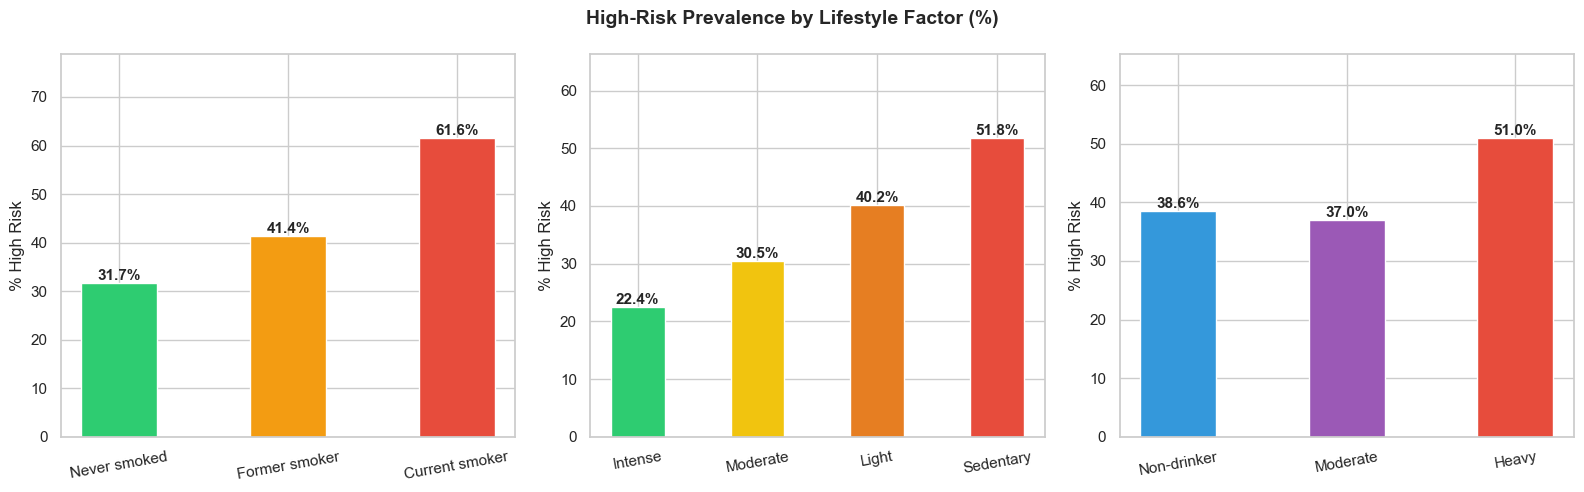

In [9]:
"""
High-risk prevalence by smoking status, physical activity, and alcohol use.
I order the categories from healthiest to riskiest within each chart so
the gradient of risk is visually intuitive.
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("High-Risk Prevalence by Lifestyle Factor (%)",
             fontsize=14, fontweight="bold")

lifestyle_configs = [
    (
        axes[0], "smoking",
        ["Never smoked", "Former smoker", "Current smoker"],
        ["#2ECC71", "#F39C12", "#E74C3C"],
    ),
    (
        axes[1], "physical_activity",
        ["Intense", "Moderate", "Light", "Sedentary"],
        ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"],
    ),
    (
        axes[2], "alcohol_use",
        ["Non-drinker", "Moderate", "Heavy"],
        ["#3498DB", "#9B59B6", "#E74C3C"],
    ),
]

for ax, col, order, colors in lifestyle_configs:
    vals = df.groupby(col)["cardiovascular_risk"].mean().reindex(order) * 100
    bars = ax.bar(vals.index, vals.values,
                  color=colors, edgecolor="white", width=0.45)
    for bar, v in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + 0.5,
            f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold",
        )
    ax.set_ylabel("% High Risk")
    ax.set_ylim(0, vals.max() * 1.28)
    ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
save_plot("06_lifestyle")
plt.show()

#### Risk by Age Group and Sex

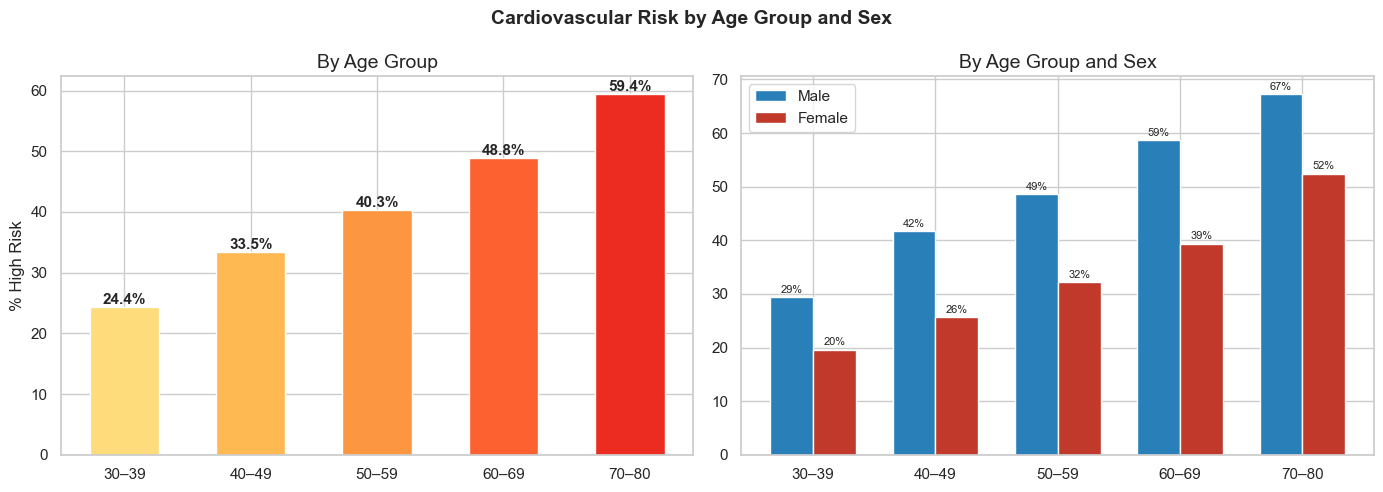

In [10]:
"""
Cardiovascular risk stratified by age group and sex.
"""

df["age_group"] = pd.cut(
    df["age"],
    bins=[29, 39, 49, 59, 69, 80],
    labels=["30–39", "40–49", "50–59", "60–69", "70–80"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cardiovascular Risk by Age Group and Sex",
             fontsize=14, fontweight="bold")

# Overall by age group 
age_risk = (
    df.groupby("age_group", observed=True)["cardiovascular_risk"].mean() * 100
)
age_colors = plt.cm.YlOrRd([int(x) for x in range(60, 230, 30)])
bars = axes[0].bar(age_risk.index, age_risk.values,
                   color=age_colors, edgecolor="white", width=0.55)
for bar, v in zip(bars, age_risk.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, v + 0.5,
        f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold",
    )
axes[0].set_title("By Age Group")
axes[0].set_ylabel("% High Risk")

# By age group and sex 
age_sex_risk = (
    df.groupby(["age_group", "sex"], observed=True)["cardiovascular_risk"]
    .mean()
    .unstack() * 100
)
x = np.arange(len(age_sex_risk))
w = 0.35
b1 = axes[1].bar(x - w / 2, age_sex_risk["Male"],   w,
                 color=COLOR_MALE, label="Male",   edgecolor="white")
b2 = axes[1].bar(x + w / 2, age_sex_risk["Female"], w,
                 color=COLOR_FEM,  label="Female", edgecolor="white")
for group_bars in [b1, b2]:
    for bar in group_bars:
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, h + 0.4,
            f"{h:.0f}%", ha="center", va="bottom", fontsize=8,
        )
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_sex_risk.index)
axes[1].set_title("By Age Group and Sex")
axes[1].legend()

plt.tight_layout()
save_plot("07_age_sex")
plt.show()

df.drop(columns=["age_group"], inplace=True)  # remove temp column

#### Comorbidity Impact

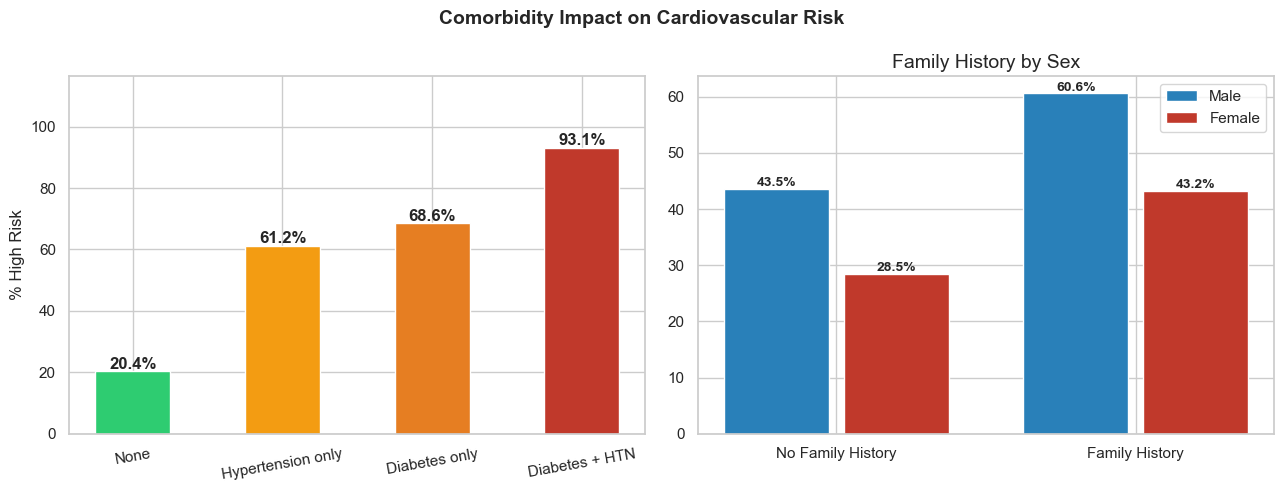

In [11]:
"""
I create a temporary group label to isolate four combinations:
none, hypertension only, diabetes only, and both.
"""

df["_comorbidity"] = "None"
df.loc[(df.diabetes == 1) & (df.hypertension == 0), "_comorbidity"] = "Diabetes only"
df.loc[(df.diabetes == 0) & (df.hypertension == 1), "_comorbidity"] = "Hypertension only"
df.loc[(df.diabetes == 1) & (df.hypertension == 1), "_comorbidity"] = "Diabetes + HTN"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comorbidity Impact on Cardiovascular Risk",
             fontsize=14, fontweight="bold")

# Comorbidity groups
group_order  = ["None", "Hypertension only", "Diabetes only", "Diabetes + HTN"]
group_risk   = (
    df.groupby("_comorbidity")["cardiovascular_risk"]
    .mean()
    .reindex(group_order) * 100
)
group_colors = ["#2ECC71", "#F39C12", "#E67E22", "#C0392B"]
bars = axes[0].bar(group_risk.index, group_risk.values,
                   color=group_colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, group_risk.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, v + 0.8,
        f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold",
    )
axes[0].set_ylabel("% High Risk")
axes[0].set_ylim(0, group_risk.max() * 1.25)
axes[0].tick_params(axis="x", rotation=10)

# Family history by sex 
fam_risk = (
    df.groupby(["family_history_cvd", "sex"])["cardiovascular_risk"]
    .mean()
    .unstack() * 100
)
fam_risk.index = ["No Family History", "Family History"]
x = np.arange(2)
b1 = axes[1].bar(x - 0.2, fam_risk["Male"],   0.35,
                 color=COLOR_MALE, label="Male",   edgecolor="white")
b2 = axes[1].bar(x + 0.2, fam_risk["Female"], 0.35,
                 color=COLOR_FEM,  label="Female", edgecolor="white")
for group_bars in [b1, b2]:
    for bar in group_bars:
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, h + 0.5,
            f"{h:.1f}%", ha="center", fontsize=10, fontweight="bold",
        )
axes[1].set_xticks(x)
axes[1].set_xticklabels(fam_risk.index)
axes[1].set_title("Family History by Sex")
axes[1].legend()

plt.tight_layout()
save_plot("08_comorbidities")
plt.show()

df.drop(columns=["_comorbidity"], inplace=True)

#### Relationships Between Key Variables

Scatter plots reveal joint distributions and help identify interaction effects
that univariate summaries miss. I use a random subsample of 1,200 patients
to keep the plots readable.

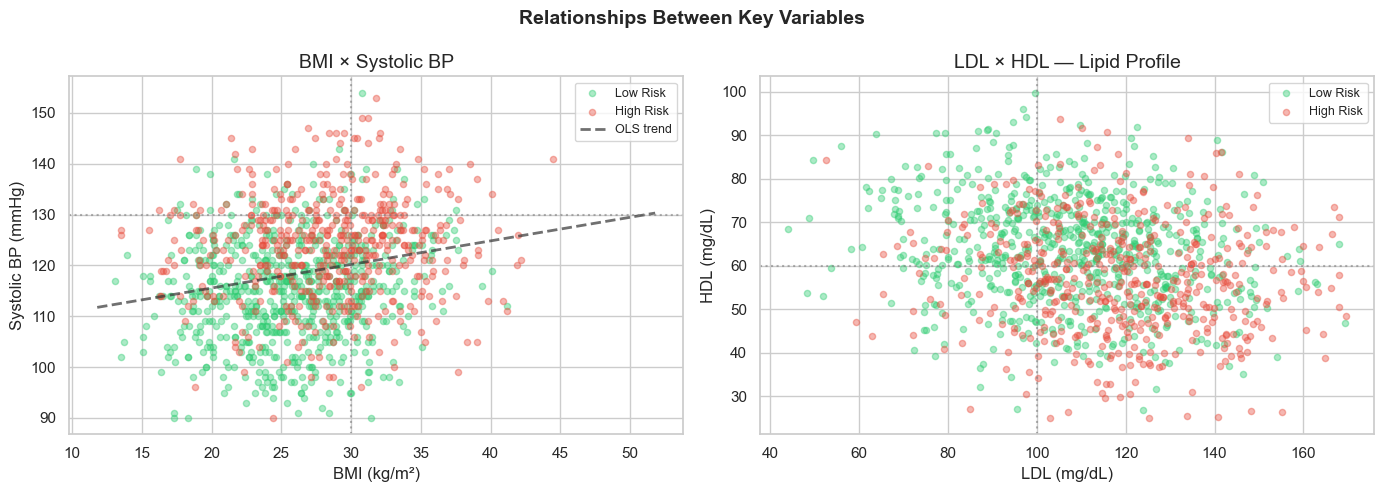

In [12]:
"""
Scatter plots for BMI vs Systolic BP, and LDL vs HDL.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Relationships Between Key Variables",
             fontsize=14, fontweight="bold")

sample = df.sample(1_200, random_state=42)

# BMI × Systolic BP 
for label, grp, color in [
    ("Low Risk",  sample[sample.cardiovascular_risk == 0], COLOR_LOW),
    ("High Risk", sample[sample.cardiovascular_risk == 1], COLOR_HIGH),
]:
    axes[0].scatter(grp["bmi"], grp["systolic_bp_mmhg"],
                    alpha=0.4, color=color, s=20, label=label)

z  = np.polyfit(df["bmi"], df["systolic_bp_mmhg"], 1)
xl = np.linspace(df["bmi"].min(), df["bmi"].max(), 100)
axes[0].plot(xl, np.poly1d(z)(xl), "--", color="#333",
             linewidth=2, alpha=0.7, label="OLS trend")
axes[0].axhline(130, color="gray", linestyle=":", alpha=0.6)   # HTN threshold
axes[0].axvline(30,  color="gray", linestyle=":", alpha=0.6)   # obesity threshold
axes[0].set_xlabel("BMI (kg/m²)")
axes[0].set_ylabel("Systolic BP (mmHg)")
axes[0].set_title("BMI × Systolic BP")
axes[0].legend(fontsize=9)

# LDL × HDL 
for label, grp, color in [
    ("Low Risk",  sample[sample.cardiovascular_risk == 0], COLOR_LOW),
    ("High Risk", sample[sample.cardiovascular_risk == 1], COLOR_HIGH),
]:
    axes[1].scatter(grp["ldl_mg_dl"], grp["hdl_mg_dl"],
                    alpha=0.4, color=color, s=20, label=label)
axes[1].axhline(60,  color="gray", linestyle=":", alpha=0.6)   # ideal HDL floor
axes[1].axvline(100, color="gray", linestyle=":", alpha=0.6)   # optimal LDL ceiling
axes[1].set_xlabel("LDL (mg/dL)")
axes[1].set_ylabel("HDL (mg/dL)")
axes[1].set_title("LDL × HDL — Lipid Profile")
axes[1].legend(fontsize=9)

plt.tight_layout()
save_plot("09_scatter")
plt.show()

#### Feature Ranking. Mean Difference Between Groups

I compute the percentage difference between group means (High Risk, Low Risk)
for every numeric variable. This diverging bar chart provides a single,
model-free view of which features discriminate best between classes.

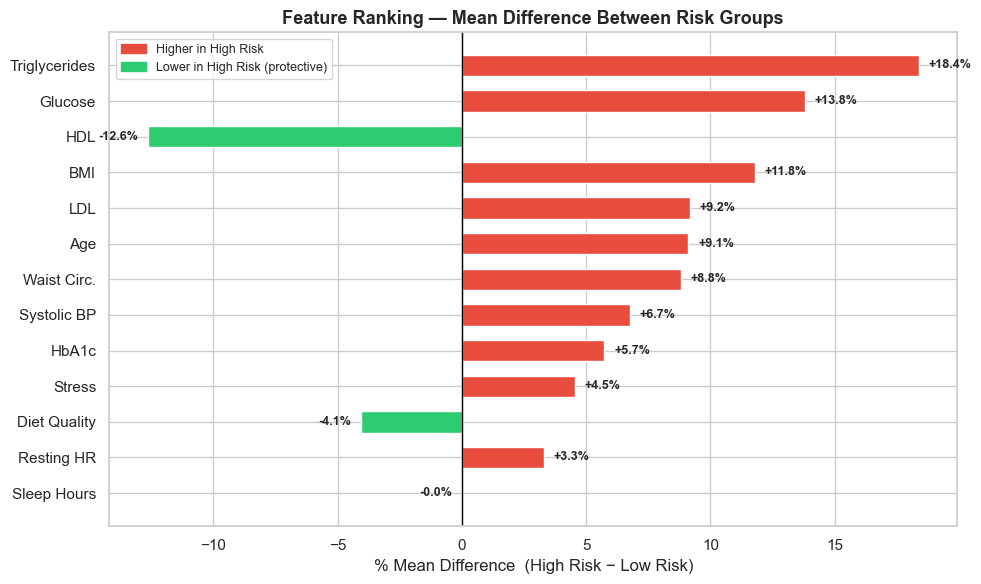

In [13]:
"""
Diverging bar chart of percentage mean difference between risk groups.
"""

numeric_cols = [
    "age", "bmi", "systolic_bp_mmhg", "ldl_mg_dl", "hdl_mg_dl",
    "triglycerides_mg_dl", "fasting_glucose_mg_dl", "hba1c_pct",
    "resting_hr_bpm", "stress_level", "waist_circumference_cm",
    "diet_quality", "sleep_hours",
]

numeric_labels = [
    "Age", "BMI", "Systolic BP", "LDL", "HDL", "Triglycerides",
    "Glucose", "HbA1c", "Resting HR", "Stress", "Waist Circ.",
    "Diet Quality", "Sleep Hours",
]

mean_high  = df[df.cardiovascular_risk == 1][numeric_cols].mean()
mean_low   = df[df.cardiovascular_risk == 0][numeric_cols].mean()
pct_diff   = (mean_high - mean_low) / mean_low * 100

rank_df = (
    pd.DataFrame({"Feature": numeric_labels, "diff": pct_diff.values})
    .assign(abs_diff=lambda x: x["diff"].abs())
    .sort_values("abs_diff")
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLOR_HIGH if v > 0 else COLOR_LOW for v in rank_df["diff"]]
bars = ax.barh(rank_df["Feature"], rank_df["diff"],
               color=colors, edgecolor="white", height=0.6)
for bar, v in zip(bars, rank_df["diff"]):
    offset = 0.4 if v > 0 else -0.4
    ax.text(
        v + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{v:+.1f}%",
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=9, fontweight="bold",
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("% Mean Difference  (High Risk − Low Risk)")
ax.set_title("Feature Ranking — Mean Difference Between Risk Groups",
             fontsize=13, fontweight="bold")
ax.legend(
    handles=[
        mpatches.Patch(color=COLOR_HIGH, label="Higher in High Risk"),
        mpatches.Patch(color=COLOR_LOW,  label="Lower in High Risk (protective)"),
    ],
    fontsize=9,
)

plt.tight_layout()
save_plot("10_feature_ranking")
plt.show()

#### EDA Summary

Key takeaways from this exploratory analysis:

| Finding | Clinical implication |
|---|---|
| Glycaemic markers (glucose, HbA1c) are most correlated with risk | Diabetes status is a dominant predictor |
| HDL is negatively correlated, a protective factor | LDL/HDL ratio likely more informative than LDL alone |
| Current smokers have ~2× higher prevalence than non-smokers | Smoking cessation is the single highest-impact intervention |
| Sedentary patients show ~45 pp higher risk than active patients | Physical activity is a strong modifiable factor |
| Diabetes + Hypertension combination carries the highest risk | Comorbidity management deserves priority in screening |

These insights will guide feature engineering and model interpretation in Notebooks 03 and 04.